**Paso 1: Instalar e importar las librerías necesarias**

In [1]:
!pip install tensorflow

In [2]:
!pip install pillow

In [3]:
!pip install kaggle

In [4]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

**Paso 2: Configuración de parámetros**

In [5]:
DATASET_ORIGINAL = 'train' # Carpeta con las 25.000 imágenes originales
DATASET_PREPARADO = 'dataset' # Carpeta nueva que voy a crear organizando las imágenes
IMG_ANCHO = 224
IMG_ALTO = 224
IMG_FORMA = (224, 224, 3) # Alto x Ancho x Canales de color (3 = RGB)
BATCH_SIZE = 32 # 32 imágenes por lote
PROPORCION_VALIDACION = 0.2 # Del total de imágenes, uso el 80 % para entrenar y el 20 % para validar
EPOCAS = 5
SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print('Configuración:')
print(f'- Tamaño de la imagen: {IMG_ANCHO} x {IMG_ALTO} píxeles')
print(f'- Tamaño del lote: {BATCH_SIZE} imágenes')
print(f'- Épocas: {EPOCAS}')

Configuración:
- Tamaño de la imagen: 224 x 224 píxeles
- Tamaño del lote: 32 imágenes
- Épocas: 5


**Paso 3: Organizar el dataset**

In [6]:
from google.colab import files
import zipfile
import os

# Subir el archivo
print('Seleccionar el archivo dogs-vs-cats.zip de la PC')
uploaded = files.upload()

# Obtener el nombre del archivo subido
zip_filename = list(uploaded.keys())[0]

# Descomprimir
print(f'Descomprimiendo {zip_filename}...')
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('.')

# La carpeta 'train' se crea dentro de la carpeta 'dogs-vs-cats' al descomprimir
# Necesito mover el contenido de 'dogs-vs-cats/train' a la raíz o especificar la ruta correcta
# Asumiendo que 'train' es la carpeta de interés dentro del zip,
# verifico si la carpeta 'train' existe directamente o dentro de 'dogs-vs-cats'
if os.path.exists('train'):
    print(f'¡Listo! Imágenes en train/: {len(os.listdir("train"))}')
elif os.path.exists('dogs-vs-cats/train'):
    # Si el zip crea una carpeta 'dogs-vs-cats' que contiene 'train', muevo los archivos
    print('Moviendo contenido de dogs-vs-cats/train a train/')
    if not os.path.exists('train'):
        os.makedirs('train')
    for item in os.listdir('dogs-vs-cats/train'):
        shutil.move(os.path.join('dogs-vs-cats/train', item), 'train')
    print(f'¡Listo! Imágenes en train/: {len(os.listdir("train"))}')
else:
    print('No se encontró la carpeta "train" después de la descompresión.')
    print(f'Contenido de la carpeta actual: {os.listdir()}')

Seleccionar el archivo dogs-vs-cats.zip de la PC


Saving dogs-vs-cats.zip to dogs-vs-cats.zip
Descomprimiendo dogs-vs-cats.zip...
Moviendo contenido de dogs-vs-cats/train a train/
¡Listo! Imágenes en train/: 25000


In [7]:
def organizar_dataset(carpeta_origen, carpeta_destino, proporcion_val=0.2):
    """
    Organiza las imágenes en subcarpetas por clase (cat/dog)
    y las divide en entrenamiento (80 %) y validación (20 %).
    """
    if os.path.exists(carpeta_destino):
        print(f'La carpeta "{carpeta_destino}" ya existe.')
        return

    print('Organizando el dataset...')

    # Creo las 4 subcarpetas necesarias
    for split in ['train', 'validation']:
        for clase in ['cat', 'dog']:
            os.makedirs(os.path.join(carpeta_destino, split, clase), exist_ok=True)

    # Obtengo la lista de todas las imágenes
    todas = os.listdir(carpeta_origen)
    gatos = [f for f in todas if f.startswith('cat')]
    perros = [f for f in todas if f.startswith('dog')]

    print(f'Imágenes de gatos: {len(gatos)}')
    print(f'Imágenes de perros: {len(perros)}')

    def copiar_imagenes(lista, clase, carpeta_origen, carpeta_destino, proporcion_val):
        """Copia las imágenes divididas en train y test"""
        random.shuffle(lista)

        # Calculo cuántas imágenes van a test
        n_val = int(len(lista) * proporcion_val)

        val_imagenes = lista[:n_val] # Las primeras n_val van a test
        train_imagenes = lista[n_val:] # El resto va a train

        # Copio a test
        for img in val_imagenes:
            src = os.path.join(carpeta_origen, img)
            dst = os.path.join(carpeta_destino, 'validation', clase, img)
            shutil.copy(src, dst)

        # Copio a train
        for img in train_imagenes:
            src = os.path.join(carpeta_origen, img)
            dst = os.path.join(carpeta_destino, 'train', clase, img)
            shutil.copy(src, dst)

        return len(train_imagenes), len(val_imagenes)

    # Copio gatos y perros
    train_gatos, val_gatos = copiar_imagenes(gatos, 'cat', carpeta_origen, carpeta_destino, proporcion_val)
    train_perros, val_perros = copiar_imagenes(perros, 'dog', carpeta_origen, carpeta_destino, proporcion_val)

    print(f'\nDataset organizado correctamente:')
    print(f'   Train gatos: {train_gatos} | Train perros: {train_perros} | Total: {train_gatos + train_perros}')
    print(f'   Test gatos: {val_gatos} | Test perros: {val_perros} | Total: {val_gatos + val_perros}')

# Ejecuto la función
organizar_dataset(DATASET_ORIGINAL, DATASET_PREPARADO, PROPORCION_VALIDACION)

Organizando el dataset...
Imágenes de gatos: 12500
Imágenes de perros: 12500

Dataset organizado correctamente:
   Train gatos: 10000 | Train perros: 10000 | Total: 20000
   Test gatos: 2500 | Test perros: 2500 | Total: 5000


**Paso 4: Cargar las imágenes con ImageDataGenerator**

In [8]:
# Generador para TRAIN (con data augmentation)
# Data augmentation = crear variaciones artificiales para que el modelo aprenda mejor
generador_train = ImageDataGenerator(
    rescale = 1./255, # Normalizar: convertir píxeles de [0,255] a [0,1]
    rotation_range = 20, # Rotar la imagen aleatoriamente
    horizontal_flip = True, # Voltear horizontalmente
    zoom_range = 0.1, # Hacer zoom de hasta 10 %
    width_shift_range = 0.1, # Desplazar horizontalmente hasta 10 %
    height_shift_range = 0.1 # Desplazar verticalmente hasta 10 %
)

# Generador para TEST (sin data augmentation)
generador_val = ImageDataGenerator(rescale=1./255)

# Conectar los generadores con las carpetas
datos_train = generador_train.flow_from_directory(
    directory = os.path.join(DATASET_PREPARADO, 'train'),
    target_size = (IMG_ALTO, IMG_ANCHO), # Redimensionar todas las imágenes a 224 x 224
    batch_size = BATCH_SIZE,
    class_mode = 'categorical', # Etiquetas: [1,0]=gato, [0,1]=perro
    seed = SEMILLA
)

datos_val = generador_val.flow_from_directory(
    directory = os.path.join(DATASET_PREPARADO, 'validation'),
    target_size = (IMG_ALTO, IMG_ANCHO),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    seed = SEMILLA
)

print(f'\nClases detectadas: {datos_train.class_indices}')
print('(0 = cat/gato, 1 = dog/perro)')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.

Clases detectadas: {'cat': 0, 'dog': 1}
(0 = cat/gato, 1 = dog/perro)


**Paso 5: Visualizar las imágenes**

GATOS


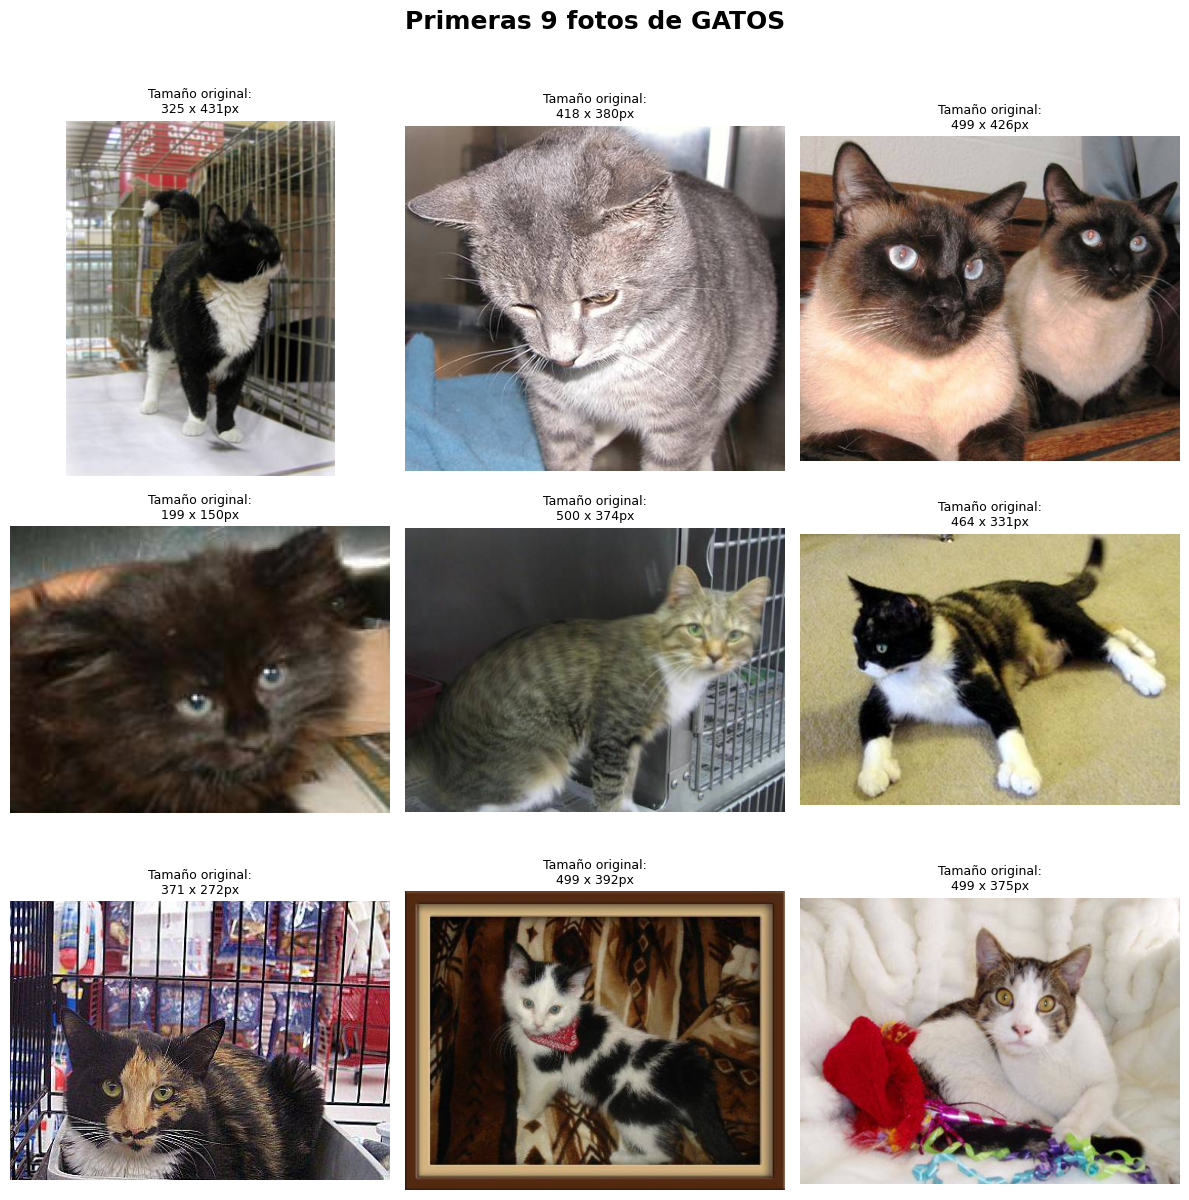

Las imágenes tienen tamaños diferentes. Se redimensionan a 224 x 224 píxeles.

PERROS


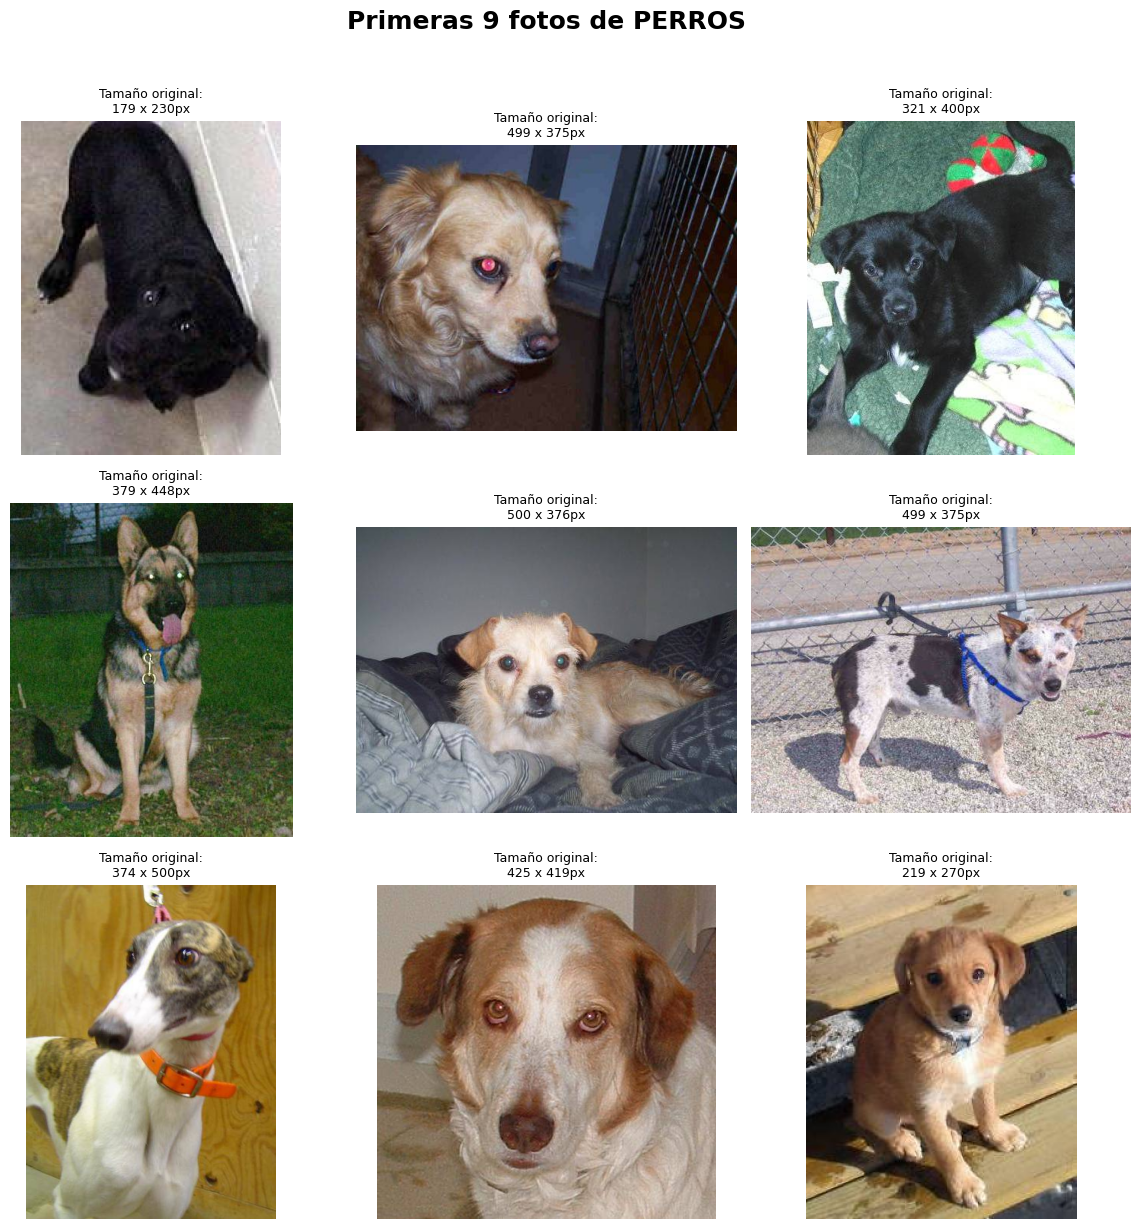

Las imágenes tienen tamaños diferentes. Se redimensionan a 224 x 224 píxeles.


In [9]:
def mostrar_muestras(carpeta_clase, titulo, n_filas=3, n_cols=3):
    """
    Muestra una cuadrícula de imágenes de ejemplo de una clase.
    """
    imagenes = os.listdir(carpeta_clase)[:n_filas * n_cols]

    fig, axes = plt.subplots(n_filas, n_cols, figsize=(12, 12))
    fig.suptitle(titulo, fontsize=18, fontweight='bold', y=1.02)

    for i, (ax, nombre_imagen) in enumerate(zip(axes.flat, imagenes)):
        ruta = os.path.join(carpeta_clase, nombre_imagen)
        img  = Image.open(ruta)

        # Muestro la imagen
        ax.imshow(img)
        ax.set_title(f'Tamaño original:\n{img.size[0]} x {img.size[1]}px', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print(f'Las imágenes tienen tamaños diferentes. Se redimensionan a {IMG_ANCHO} x {IMG_ALTO} píxeles.')

# Quiero mostrar 9 gatos
print('GATOS')
mostrar_muestras(
    carpeta_clase = os.path.join(DATASET_PREPARADO, 'train', 'cat'),
    titulo = 'Primeras 9 fotos de GATOS'
)

# Quiero mostrar 9 perros
print('\nPERROS')
mostrar_muestras(
    carpeta_clase = os.path.join(DATASET_PREPARADO, 'train', 'dog'),
    titulo = 'Primeras 9 fotos de PERROS'
)

**Paso 6: Construcción de una RNA**

Se está usando la arquitectura **VGG16**, una red neuronal convolucional (CNN) muy famosa que ganó una competición de Kaggle en 2014.

**¿Cómo funciona?**
- **`Conv2D`** detecta patrones: bordes, texturas, orejas, bigotes, etc.
- **`MaxPool2D`** reduce el tamaño para quedarse solo con lo importante-
- **`Flatten`** convierte la imagen en una lista de números.
- **`Dense`** toma esos números y decide: ¿perro o gato?

In [10]:
modelo = Sequential(name='VGG16_CatsVsDogs')

# BLOQUE 1: Detectar patrones simples (bordes, líneas)
modelo.add(Conv2D(input_shape=IMG_FORMA, filters=64, kernel_size=(3,3), padding='same', activation='relu', name='conv1_1'))
modelo.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu', name='conv1_2'))
modelo.add(MaxPool2D(pool_size=(2,2), strides=(2,2), name='pool1'))
# Después de este bloque: 112x112x64

# BLOQUE 2: Detectar patrones más complejos (texturas)
modelo.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu', name='conv2_1'))
modelo.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu', name='conv2_2'))
modelo.add(MaxPool2D(pool_size=(2,2), strides=(2,2), name='pool2'))
# Después de este bloque: 56x56x128

# BLOQUE 3: Detectar formas (ojos, nariz, orejas)
modelo.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu', name='conv3_1'))
modelo.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu', name='conv3_2'))
modelo.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu', name='conv3_3'))
modelo.add(MaxPool2D(pool_size=(2,2), strides=(2,2), name='pool3'))
# Después de este bloque: 28x28x256

# BLOQUE 4: Detectar características específicas
modelo.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu', name='conv4_1'))
modelo.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu', name='conv4_2'))
modelo.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu', name='conv4_3'))
modelo.add(MaxPool2D(pool_size=(2,2), strides=(2,2), name='pool4'))
# Después de este bloque: 14x14x512

# BLOQUE 5: Refinar las características detectadas
modelo.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu', name='conv5_1'))
modelo.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu', name='conv5_2'))
modelo.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu', name='conv5_3'))
modelo.add(MaxPool2D(pool_size=(2,2), strides=(2,2), name='pool5'))
# Después de este bloque: 7x7x512

# CABEZA CLASIFICADORA: Tomar la decisión final
modelo.add(Flatten(name='flatten')) # 7x7x512 = 25.088 números
modelo.add(Dense(units=4096, activation='relu', name='fc1')) # Capa densa grande
modelo.add(Dense(units=4096, activation='relu', name='fc2')) # Otra capa densa grande
modelo.add(Dense(units=2, activation='softmax', name='predictions')) # Salida: [prob_gato, prob_perro]

# Resumen del modelo
print('Arquitectura del modelo:')
modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Arquitectura del modelo:


Model: "VGG16_CatsVsDogs"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_3 (Conv2D)                │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_2 (Conv2D)                │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_3 (Conv2D)                │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5_1 (Conv2D)                │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5_2 (Conv2D)                │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5_3 (Conv2D)                │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 134,268,738 (512.19 MB)

 Non-trainable params: 0 (0.00 B)

**Paso 7: Compilar el modelo**

In [11]:
# Compilar = configurar cómo aprende el modelo
modelo.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

print('Modelo compilado correctamente')
print('Algoritmo de optimización: Adam')
print('Función de pérdida: Categorical Crossentropy')
print('Métrica a monitorear: Accuracy')

Modelo compilado correctamente
Algoritmo de optimización: Adam
Función de pérdida: Categorical Crossentropy
Métrica a monitorear: Accuracy


**Paso 8: Configurar los callbacks**

- **`ModelCheckpoint`**: Guarda el modelo automáticamente cuando su rendimiento mejora.
- **`EarlyStopping`**: Para el entrenamiento cuando el modelo deja de mejorar, es decir, evita el sobreentrenamiento (overfitting).

In [12]:
# Creo la carpeta donde voy a guardar el modelo
os.makedirs('models', exist_ok=True)

# ModelCheckpoint:
checkpoint = ModelCheckpoint(
    filepath = 'models/mejor_modelo.keras', # Ruta donde guardar
    monitor = 'val_accuracy', # Monitorea la precisión en test
    save_best_only = True, # Solo guardar si mejora el resultado anterior
    mode = 'max', # Quiero maximizar val_accuracy
    verbose = 1 # Muestra un mensaje
)

# EarlyStopping:
early_stopping = EarlyStopping(
    monitor = 'val_accuracy', # Monitorea la precisión en test
    patience = 3, # Espera 3 épocas sin mejora antes de parar
    restore_best_weights = True, # Al parar, carga los pesos del mejor momento
    verbose = 1 # Muestra un mensaje
)

print('Callbacks configurados:')
print('- ModelCheckpoint: Guardará el mejor modelo en models/mejor_modelo.keras')
print('- EarlyStopping: Parará si val_accuracy no mejora en 3 épocas')

Callbacks configurados:
- ModelCheckpoint: Guardará el mejor modelo en models/mejor_modelo.keras
- EarlyStopping: Parará si val_accuracy no mejora en 3 épocas


**Paso 9: Entrenar el modelo**

In [13]:
print('Iniciando entrenamiento...')
print(f'Imágenes de train: {datos_train.samples}')
print(f'Imágenes de test: {datos_val.samples}')
print(f'Épocas: {EPOCAS}')
print(f'Lote de: {BATCH_SIZE} imágenes\n')

historial = modelo.fit(
    datos_train, # Datos de entrenamiento
    epochs = EPOCAS, # Número máximo de épocas
    steps_per_epoch  = 50,
    validation_data = datos_val, # Datos para validar después de cada época
    validation_steps = 10,
    callbacks = [checkpoint, early_stopping], # Callbacks configurados antes
    verbose = 1 # Muestra un mensaje
)

print('\n¡Entrenamiento completado!')

Iniciando entrenamiento...
Imágenes de train: 20000
Imágenes de test: 5000
Épocas: 5
Lote de: 32 imágenes

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.4950 - loss: 0.7388
Epoch 1: val_accuracy improved from None to 0.54062, saving model to models/mejor_modelo.keras

Epoch 1: finished saving model to models/mejor_modelo.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.4794 - loss: 0.7104 - val_accuracy: 0.5406 - val_loss: 0.6923
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.5060 - loss: 0.6933
Epoch 2: val_accuracy did not improve from 0.54062
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 666ms/step - accuracy: 0.5063 - loss: 0.6933 - val_accuracy: 0.4656 - val_loss: 0.6938
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.4678 - loss: 0.6937
Epoch 3: val_accuracy did not improve from 0.54062
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 655ms/step - accuracy: 0.5000 - loss: 0.6933 - val_accuracy: 0.5188 - val_loss: 0.6927
Epoch 4/5
50/50 ━━━━━━━━━━━━

**Paso 10: Visualizar el entrenamiento**

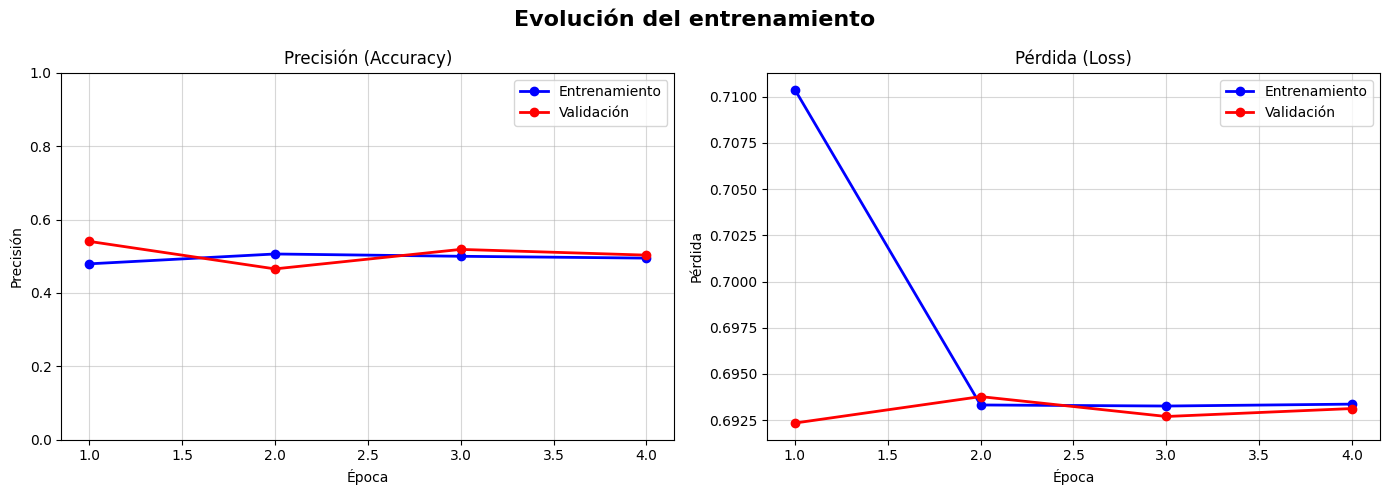


Mejor precisión en test: 54.06 %
Alcanzada en la época: 1
El modelo generaliza bien.


In [16]:
# Graficar la evolución del entrenamiento
epocas_reales = range(1, len(historial.history['accuracy']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evolución del entrenamiento', fontsize=16, fontweight='bold')

# Gráfica 1: Precisión
ax1.plot(epocas_reales, historial.history['accuracy'], 'b-o', label='Entrenamiento', linewidth=2)
ax1.plot(epocas_reales, historial.history['val_accuracy'], 'r-o', label='Validación', linewidth=2)
ax1.set_title('Precisión (Accuracy)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True, alpha=0.5)
ax1.set_ylim([0, 1])

# Gráfica 2: Pérdida
ax2.plot(epocas_reales, historial.history['loss'], 'b-o', label='Entrenamiento', linewidth=2)
ax2.plot(epocas_reales, historial.history['val_loss'], 'r-o', label='Validación', linewidth=2)
ax2.set_title('Pérdida (Loss)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

# Resumen
mejor_val_accuracy = max(historial.history['val_accuracy'])
mejor_epoca = historial.history['val_accuracy'].index(mejor_val_accuracy) + 1
print(f'\nMejor precisión en test: {mejor_val_accuracy*100:.2f} %')
print(f'Alcanzada en la época: {mejor_epoca}')

# Diagnóstico de sobreajuste
ultima_train = historial.history['accuracy'][-1]
ultima_val = historial.history['val_accuracy'][-1]
diferencia = ultima_train - ultima_val

if diferencia > 0.15:
    print('Posible sobreajuste (overfitting): El modelo memorizó los datos de entrenamiento.')
    print('Sugerencia: Aumentar el data augmentation.')
else:
    print('El modelo generaliza bien.')

**Paso 11: Cargar el mejor modelo y evaluar**

In [17]:
print('Cargando el mejor modelo guardado por ModelCheckpoint...')
mejor_modelo = load_model('models/mejor_modelo.keras')

print('\nEvaluando en el conjunto de test...')
perdida, precision = mejor_modelo.evaluate(datos_val, verbose=1)

print(f'\nResultados del mejor modelo:')
print(f'- Pérdida (Loss): {perdida:.4f}')
print(f'- Precisión: {precision:.4f} | ({precision*100:.2f} %)')

Cargando el mejor modelo guardado por ModelCheckpoint...

Evaluando en el conjunto de test...
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 180ms/step - accuracy: 0.5000 - loss: 0.6932

Resultados del mejor modelo:
- Pérdida (Loss): 0.6932
- Precisión: 0.5000 | (50.00 %)


**Paso 12: Hacer predicciones en imágenes nuevas**

Predicciones en imágenes de GATOS


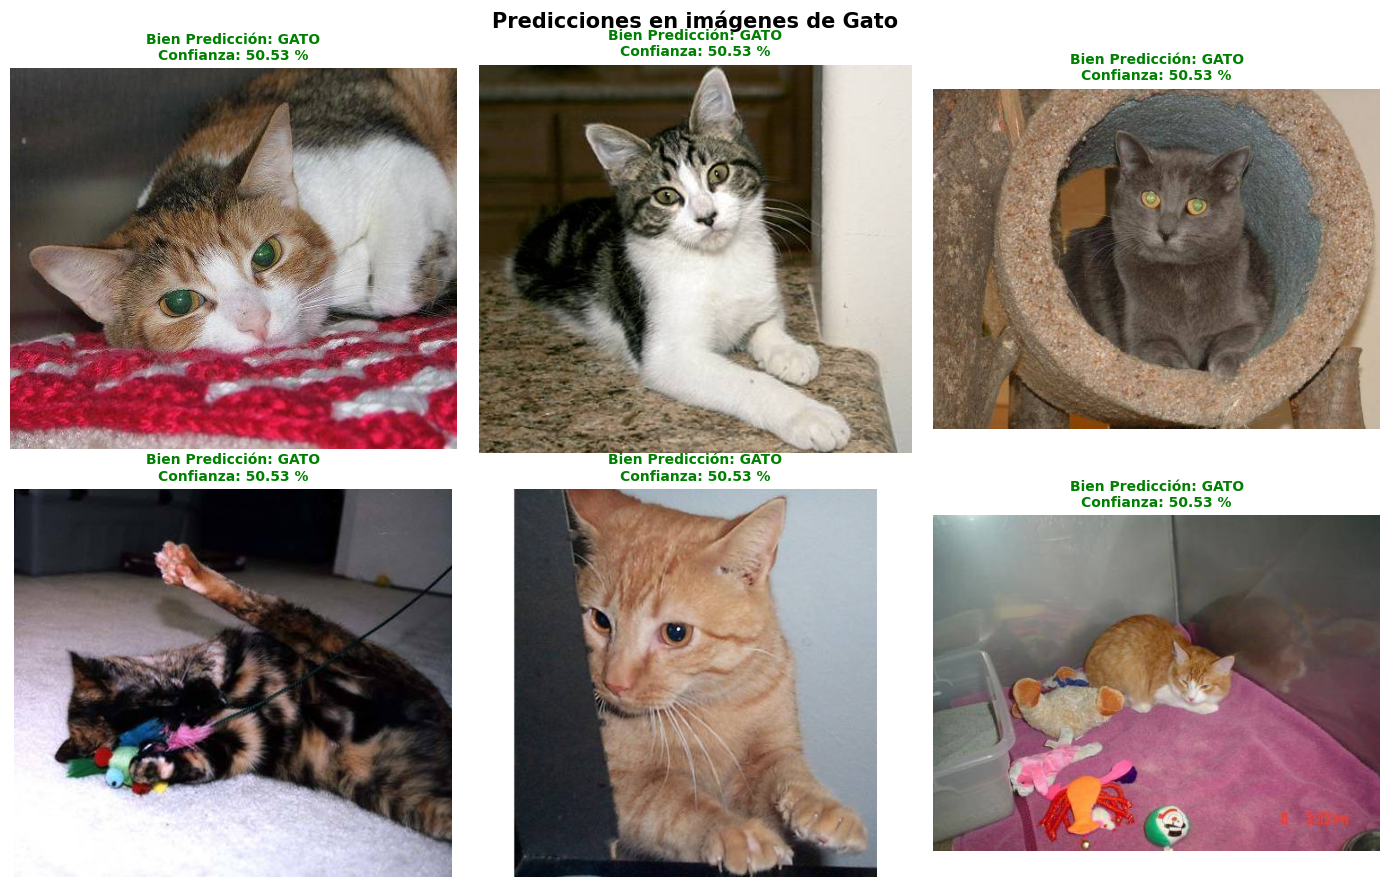


Predicciones en imágenes de PERROS


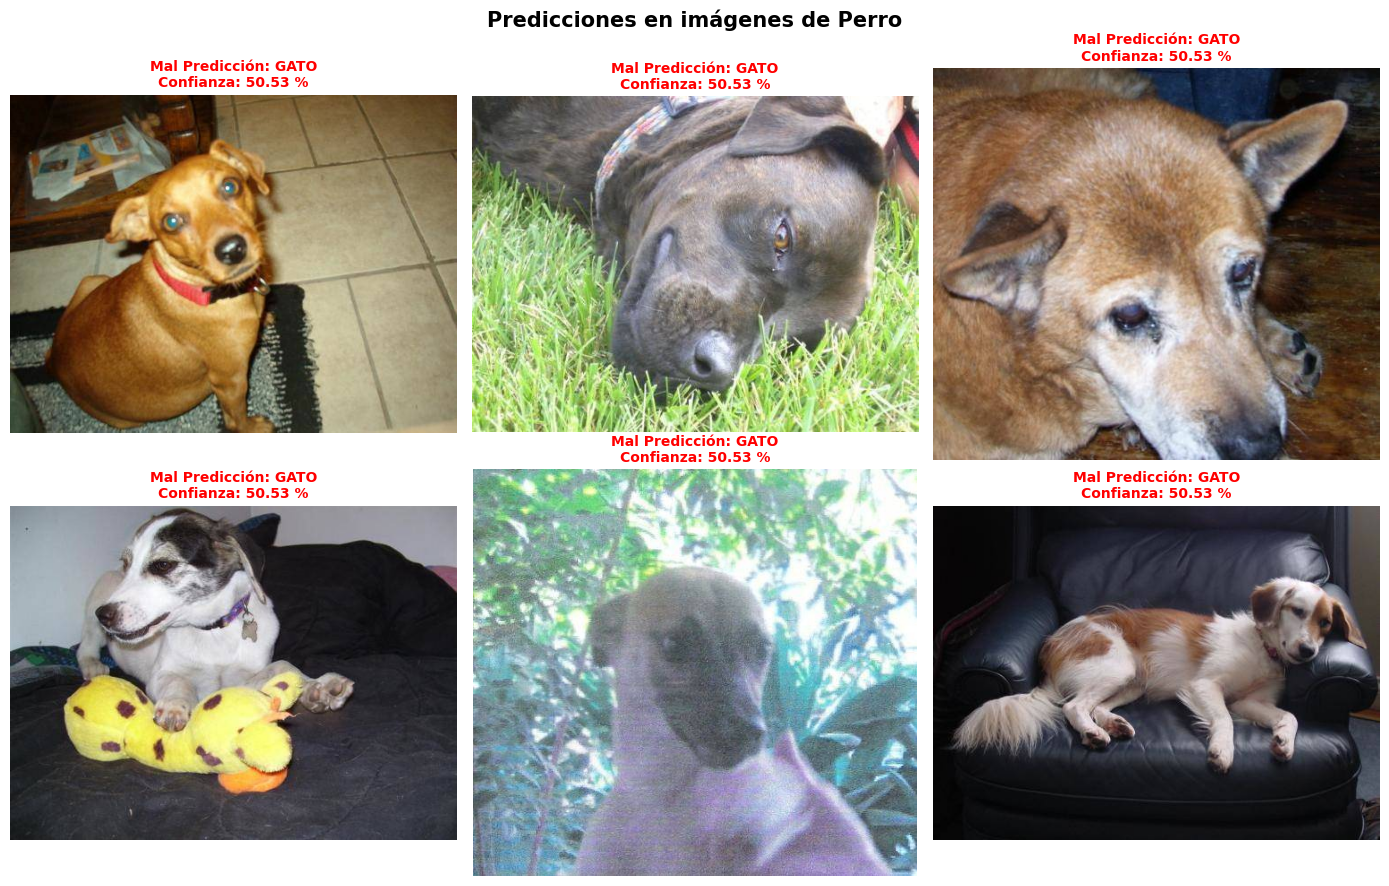

In [18]:
def predecir_imagen(ruta_imagen, modelo):
    """
    Dada una imagen, el modelo predice si es un perro o un gato.
    Devuelve la etiqueta predicha y su nivel de confianza.
    """
    # Cargo y preparo la imagen
    img = Image.open(ruta_imagen).convert('RGB')
    img = img.resize((IMG_ANCHO, IMG_ALTO)) # Redimensionar a 224 x 224
    img_array = np.array(img) / 255.0 # Normalizar a [0,1]
    img_array = np.expand_dims(img_array, axis=0) # Añadir dimensión de batch: (1, 224, 224, 3)

    # Hago la predicción
    prediccion = modelo.predict(img_array, verbose=0)

    # prediccion[0] = [probabilidad_gato, probabilidad_perro]
    prob_gato = prediccion[0][0] # índice 0 = cat
    prob_perro = prediccion[0][1] # índice 1 = dog

    if prob_gato > prob_perro:
        return 'GATO', prob_gato
    else:
        return 'PERRO', prob_perro

def mostrar_predicciones(carpeta_clase, clase_real, n_imagenes=6):
    """
    Muestra predicciones para un grupo de imágenes.
    Verde = acertó, Rojo = se equivocó
    """
    archivos = random.sample(os.listdir(carpeta_clase), n_imagenes)

    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    fig.suptitle(f'Predicciones en imágenes de {clase_real}', fontsize=15, fontweight='bold')

    for ax, nombre in zip(axes.flat, archivos):
        ruta = os.path.join(carpeta_clase, nombre)

        # Predicción
        etiqueta, confianza = predecir_imagen(ruta, mejor_modelo)

        # Compruebo si acertó
        acierto = (clase_real.upper() in etiqueta.upper())
        color = 'green' if acierto else 'red'
        estado = 'Bien' if acierto else 'Mal'

        # Muestro la imagen
        img = Image.open(ruta)
        ax.imshow(img)
        ax.set_title(f'{estado} Predicción: {etiqueta}\nConfianza: {confianza*100:.2f} %',
                    color=color, fontsize=10, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Predicciones para gatos
print('Predicciones en imágenes de GATOS')
mostrar_predicciones(
    carpeta_clase = os.path.join(DATASET_PREPARADO, 'validation', 'cat'),
    clase_real = 'Gato'
)

# Predicciones para perros
print('\nPredicciones en imágenes de PERROS')
mostrar_predicciones(
    carpeta_clase = os.path.join(DATASET_PREPARADO, 'validation', 'dog'),
    clase_real = 'Perro'
)

**Paso 13: Guardar el modelo**

In [20]:
# Guardar en formato .keras
mejor_modelo.save('models/modelo_final.keras')
print('Modelo guardado en: models/modelo_final.keras')

# Guardar en formato .h5
mejor_modelo.save('models/modelo_final.h5')
print('Modelo guardado en: models/modelo_final.h5')

print('\nArchivos en la carpeta models:')
for archivo in sorted(os.listdir('models')):
    tamano = os.path.getsize(os.path.join('models', archivo))
    print(f'{archivo} ({tamano / 1024 / 1024:.2f} MB)')

Modelo guardado en: models/modelo_final.keras
Modelo guardado en: models/modelo_final.h5

Archivos en la carpeta models:
mejor_modelo.keras (1536.68 MB)
modelo_final.h5 (1536.69 MB)
modelo_final.keras (1536.68 MB)
